<a href="https://colab.research.google.com/github/I7411/THDeepLearning/blob/main/CNN_Buoi3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
#data visualization packages
import matplotlib.pyplot as plt

In [3]:
import pandas as pd
import numpy as np

# Đường dẫn dữ liệu MNIST có sẵn trong Google Colab
mnist_train = "/content/sample_data/mnist_train_small.csv"
mnist_test = "/content/sample_data/mnist_test.csv"

# Đọc dữ liệu
# header=None để không làm mất dòng đầu tiên
df_train = pd.read_csv(mnist_train, header=None)
df_test = pd.read_csv(mnist_test, header=None)

print("Train dataframe:", df_train.shape)
print("Test dataframe:", df_test.shape)

# Cột 0 là nhãn, các cột còn lại là pixel
X_train = df_train.iloc[:, 1:].values
y_train = df_train.iloc[:, 0].values

X_test = df_test.iloc[:, 1:].values
y_test = df_test.iloc[:, 0].values

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Train dataframe: (20000, 785)
Test dataframe: (10000, 785)
X_train: (20000, 784)
y_train: (20000,)
X_test: (10000, 784)
y_test: (10000,)


In [6]:
num_classes = 10
input_shape = (28, 28, 1)

# Chuẩn hóa pixel về [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape từ vector 784 thành ảnh 28x28x1
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("Number of classes:", len(np.unique(y_train)))
print("Classes:", np.unique(y_train))
print("First 5 labels:", y_train[:5])

X_train: (20000, 28, 28, 1)
X_test: (10000, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
First 5 labels: [6 5 7 9 5]


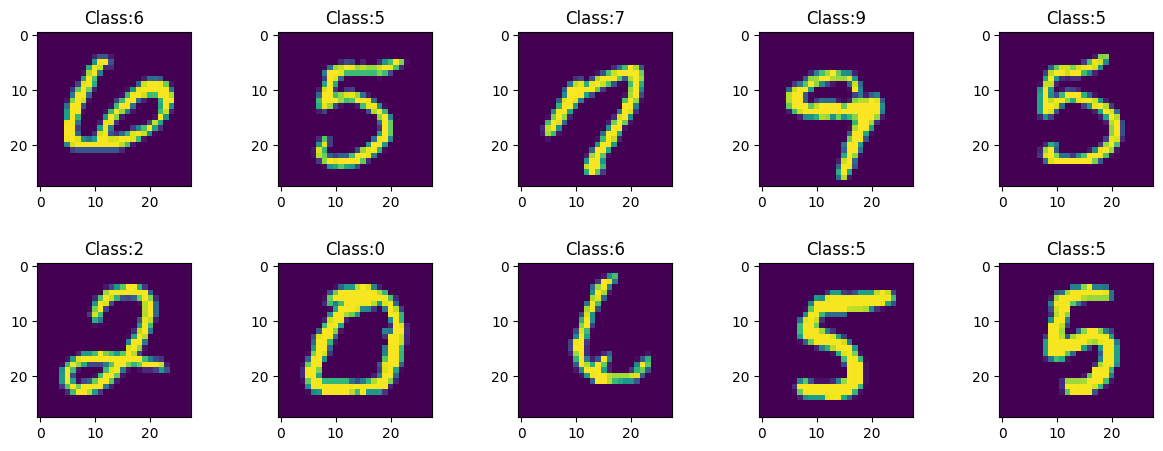

In [8]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28, 28))
  ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [9]:
y_train = keras. utils.to_categorical(y_train, num_classes)
y_test = keras.utils. to_categorical(y_test, num_classes)

In [12]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model. summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy' ])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step - accuracy: 0.1093 - loss: 2.3018 - val_accuracy: 0.1220 - val_loss: 2.2995
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - accuracy: 0.1111 - loss: 2.3014 - val_accuracy: 0.1220 - val_loss: 2.2998
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.1111 - loss: 2.3014 - val_accuracy: 0.1220 - val_loss: 2.3000
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.1111 - loss: 2.3012 - val_accuracy: 0.1220 - val_loss: 2.2996
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - accuracy: 0.1111 - loss: 2.3012 - val_accuracy: 0.1220 - val_loss: 2.2997
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.1111 - loss: 2.3012 - val_accuracy: 0.1220 - val_loss: 2.2995
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.1111 - loss: 2.3011 - val_accuracy: 0.1220 - val_loss: 2.2995
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.1111 - loss: 2.3011 - 

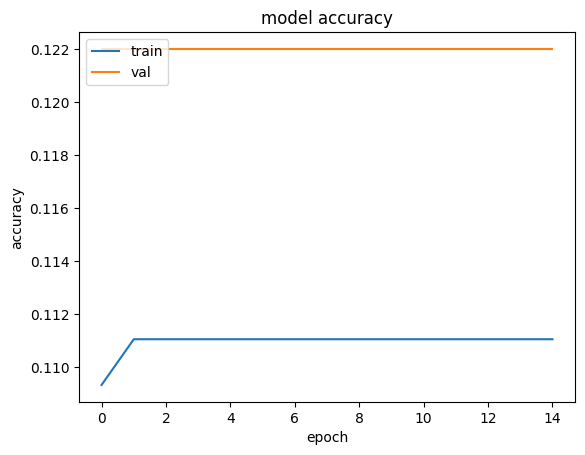

In [15]:
plt.plot(model_fit.history['accuracy' ])
plt.plot(model_fit.history['val_accuracy' ])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt. legend(['train', 'val'], loc='upper left')
plt.show()

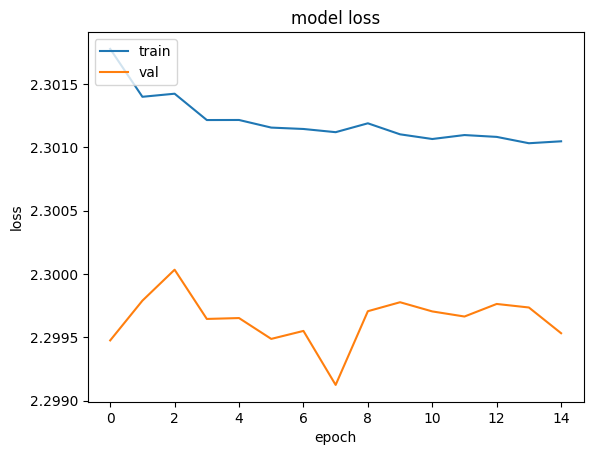

In [17]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [18]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 3s - 9ms/step - accuracy: 0.1135 - loss: 2.3013
Test loss: 2.3012826442718506
Test accuracy: 0.11349999904632568


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
[[0.09800669 0.11055191 0.0992224  0.10196631 0.09642349 0.08875446
  0.10294556 0.10511512 0.09578393 0.10123013]]
1 7


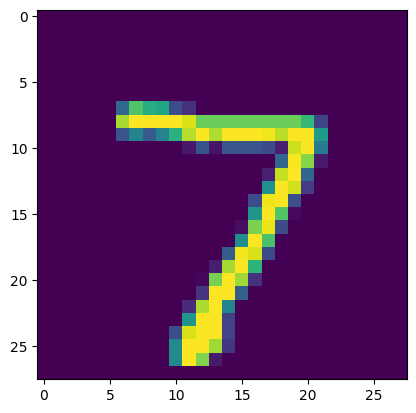

In [19]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

In [24]:
model.save("cnn.keras")

In [ ]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2